# Mutual Fund Performance Analytics

This notebook performs performance analysis on 40 mutual fund schemes using daily NAV data and other fund information. The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, and Benchmark Comparison.

In [6]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)   

In [7]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

REPORT_DIR = PROJECT_ROOT / "reports"

CHART_DIR = REPORT_DIR / "charts"

REPORT_DIR.mkdir(exist_ok=True)

CHART_DIR.mkdir(exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)

Project Root : c:\Users\moham\Desktop\MutualFundAnalytics
Data Folder  : c:\Users\moham\Desktop\MutualFundAnalytics\data\processed


In [8]:
# ============================================================
# Load Cleaned Datasets
# ============================================================

fund_master_df = pd.read_csv(
    DATA_DIR / "01_fund_master_clean.csv"
)

nav_history_df = pd.read_csv(
    DATA_DIR / "02_nav_history_clean.csv"
)

aum_by_fund_house_df = pd.read_csv(
    DATA_DIR / "03_aum_by_fund_house_clean.csv"
)

monthly_sip_inflows_df = pd.read_csv(
    DATA_DIR / "04_monthly_sip_inflows_clean.csv"
)

category_inflows_df = pd.read_csv(
    DATA_DIR / "05_category_inflows_clean.csv"
)

industry_folio_count_df = pd.read_csv(
    DATA_DIR / "06_industry_folio_count_clean.csv"
)

scheme_performance_df = pd.read_csv(
    DATA_DIR / "07_scheme_performance_clean.csv"
)

investor_transactions_df = pd.read_csv(
    DATA_DIR / "08_investor_transactions_clean.csv"
)

portfolio_holdings_df = pd.read_csv(
    DATA_DIR / "09_portfolio_holdings_clean.csv"
)

benchmark_indices_df = pd.read_csv(
    DATA_DIR / "10_benchmark_indices_clean.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [9]:
dataset_summary = pd.DataFrame({
    "Dataset":[
        "Fund Master",
        "NAV History",
        "AUM",
        "Monthly SIP",
        "Category Inflows",
        "Industry Folio Count",
        "Scheme Performance",
        "Investor Transactions",
        "Portfolio Holdings",
        "Benchmark Indices"
    ],
    "Rows":[
        len(fund_master_df),
        len(nav_history_df),
        len(aum_by_fund_house_df),
        len(monthly_sip_inflows_df),
        len(category_inflows_df),
        len(industry_folio_count_df),
        len(scheme_performance_df),
        len(investor_transactions_df),
        len(portfolio_holdings_df),
        len(benchmark_indices_df)
    ],
    "Columns":[
        fund_master_df.shape[1],
        nav_history_df.shape[1],
        aum_by_fund_house_df.shape[1],
        monthly_sip_inflows_df.shape[1],
        category_inflows_df.shape[1],
        industry_folio_count_df.shape[1],
        scheme_performance_df.shape[1],
        investor_transactions_df.shape[1],
        portfolio_holdings_df.shape[1],
        benchmark_indices_df.shape[1]
    ]
})

display(dataset_summary)

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV History,46000,3
2,AUM,90,5
3,Monthly SIP,48,7
4,Category Inflows,144,3
5,Industry Folio Count,21,7
6,Scheme Performance,40,21
7,Investor Transactions,32778,13
8,Portfolio Holdings,322,8
9,Benchmark Indices,8050,3


In [10]:
print("="*60)
print("Fund Master")
print("="*60)
display(fund_master_df.head())

print("="*60)
print("NAV History")
print("="*60)
display(nav_history_df.head())

print("="*60)
print("Scheme Performance")
print("="*60)
display(scheme_performance_df.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,14-02-2006,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,01-01-2013,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,09-09-2009,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,01-01-2013,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,30-12-2000,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History


,amfi_code,date,nav
0,100016,03-01-2022,520.4608
1,100016,04-01-2022,515.0971
2,100016,05-01-2022,521.7239
3,100016,06-01-2022,515.7880
4,100016,07-01-2022,515.1639


Scheme Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_anomaly,expense_ratio_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False,False


# Daily Return Analysis

This section computes the daily returns for all 40 mutual fund schemes using their daily NAV values. Daily returns represent the percentage change in NAV from one trading day to the next and form the foundation for all subsequent performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, and Beta.

In [11]:
# ============================================================
# Module 1 : Daily Return Analysis
# ============================================================

daily_return_df = nav_history_df.copy()

# Convert date column
daily_return_df["date"] = pd.to_datetime(
    daily_return_df["date"],
    format="%d-%m-%Y"
)

# Convert NAV
daily_return_df["nav"] = pd.to_numeric(
    daily_return_df["nav"],
    errors="coerce"
)

# Sort by fund and date
daily_return_df = daily_return_df.sort_values(
    ["amfi_code", "date"]
)

# Merge scheme names
daily_return_df = daily_return_df.merge(
    fund_master_df[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

print("=" * 60)
print("Daily Return Dataset")
print("=" * 60)

print("Total Schemes :", daily_return_df["scheme_name"].nunique())
print("Total Records :", len(daily_return_df))

display(daily_return_df.head())

Daily Return Dataset
Total Schemes : 40
Total Records : 46000


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [12]:
# Daily Return = (Today's NAV / Yesterday's NAV) - 1

daily_return_df["daily_return"] = (
    daily_return_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

display(
    daily_return_df[
        [
            "scheme_name",
            "date",
            "nav",
            "daily_return"
        ]
    ].head(15)
)

,scheme_name,date,nav,daily_return
0,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608,NaN
1,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
2,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
3,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
4,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210
...,...,...,...,...
10,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-17,514.7627,0.000776
11,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-18,517.3803,0.005085
12,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-19,513.1866,-0.008106
13,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-20,507.1294,-0.011803


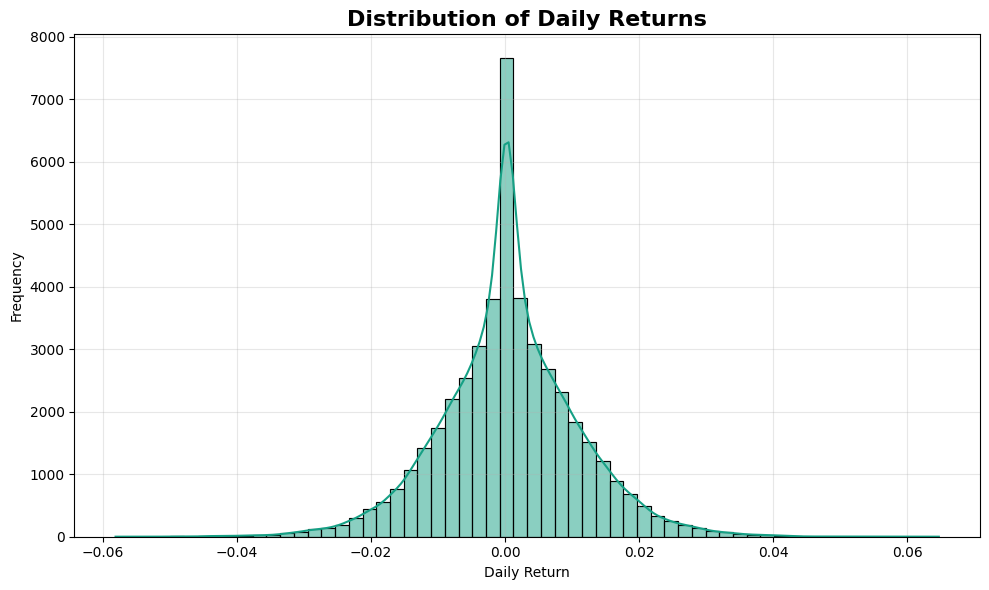

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    daily_return_df["daily_return"].dropna(),
    bins=60,
    kde=True,
    color="#16A085",
    ax=ax
)

ax.set_title(
    "Distribution of Daily Returns",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

ax.grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "01_daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
summary = daily_return_df["daily_return"].describe()

display(summary)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
top_returns = (
    daily_return_df
    .sort_values("daily_return", ascending=False)
    .head(10)
)

bottom_returns = (
    daily_return_df
    .sort_values("daily_return")
    .head(10)
)

print("Top 10 Daily Returns")
display(
    top_returns[
        [
            "scheme_name",
            "date",
            "daily_return"
        ]
    ]
)

print("Bottom 10 Daily Returns")
display(
    bottom_returns[
        [
            "scheme_name",
            "date",
            "daily_return"
        ]
    ]
)

Top 10 Daily Returns


,scheme_name,date,daily_return
24745,SBI Small Cap Fund - Regular Plan - Growth,2024-04-15,0.064713
13226,Nippon India Small Cap Fund - Regular - Growth,2024-03-19,0.059304
5207,ABSL Small Cap Fund - Regular - Growth,2024-05-01,0.054851
25566,SBI Small Cap Fund - Direct Plan - Growth,2023-01-10,0.053320
25832,SBI Small Cap Fund - Direct Plan - Growth,2024-01-17,0.051811
24155,SBI Small Cap Fund - Regular Plan - Growth,2022-01-10,0.051113
24371,SBI Small Cap Fund - Regular Plan - Growth,2022-11-08,0.049051
45082,DSP Small Cap Fund - Regular - Growth,2022-11-23,0.048490
24356,SBI Small Cap Fund - Regular Plan - Growth,2022-10-18,0.048454
25091,SBI Small Cap Fund - Regular Plan - Growth,2025-08-12,0.047123


Bottom 10 Daily Returns


,scheme_name,date,daily_return
12774,Nippon India Small Cap Fund - Regular - Growth,2022-06-24,-0.058102
4917,ABSL Small Cap Fund - Regular - Growth,2023-03-22,-0.051847
12952,Nippon India Small Cap Fund - Regular - Growth,2023-03-01,-0.050335
45312,DSP Small Cap Fund - Regular - Growth,2023-10-11,-0.048870
5560,ABSL Small Cap Fund - Regular - Growth,2025-09-08,-0.048634
19804,Axis Small Cap Fund - Regular - Growth,2022-12-23,-0.048367
13333,Nippon India Small Cap Fund - Regular - Growth,2024-08-15,-0.048305
20307,Axis Small Cap Fund - Regular - Growth,2024-11-27,-0.046524
26048,SBI Small Cap Fund - Direct Plan - Growth,2024-11-14,-0.045429
38520,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2024-03-11,-0.045218


## Summary

Daily returns were calculated for all 40 mutual fund schemes using their daily NAV values. The return distribution is centered close to zero, with most observations representing normal day-to-day market movements. A few extreme positive and negative returns indicate periods of higher market volatility, which is expected in financial markets.

#  Compound Annual Growth Rate (CAGR) Analysis

This section computes the Compound Annual Growth Rate (CAGR) for all mutual fund schemes using historical NAV data.

CAGR represents the annualized growth rate of an investment over a specified period, assuming returns are compounded annually.

### Note on Available Data

The project requirement asks for **1-Year, 3-Year, and 5-Year CAGR** calculations. However, the available NAV history spans from **03-Jan-2022 to 29-May-2026**, providing approximately **4.4 years** of data.

Therefore:

- **1-Year CAGR** is calculated using the latest available 1-year NAV history.
- **3-Year CAGR** is calculated using the latest available 3-year NAV history.
- **5-Year CAGR** is approximated using the **maximum available NAV history (approximately 4.4 years)** instead of a full five years. The CAGR formula uses the actual investment duration to ensure mathematically correct results.

This approach preserves analytical accuracy while working within the available dataset.

In [25]:

#  CAGR Analysis


cagr_df = daily_return_df.copy()

cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "date",
        "nav"
    ]
].copy()

cagr_df = cagr_df.sort_values(
    ["amfi_code", "date"]
)

print("="*60)
print("CAGR Dataset Summary")
print("="*60)

print("Schemes :", cagr_df["scheme_name"].nunique())
print("Records :", len(cagr_df))

display(cagr_df.head())

CAGR Dataset Summary
Schemes : 40
Records : 46000


,amfi_code,scheme_name,date,nav
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639


In [26]:
def calculate_cagr(nav_data, target_years):
    """
    Calculate CAGR using available NAV history.

    If the requested history is unavailable,
    the earliest available NAV is used and CAGR
    is calculated using the actual elapsed years.
    """

    nav_data = nav_data.sort_values("date")

    end_row = nav_data.iloc[-1]

    end_date = end_row["date"]
    end_nav = end_row["nav"]

    target_start = end_date - pd.DateOffset(years=target_years)

    eligible_rows = nav_data[
        nav_data["date"] >= target_start
    ]

    # If enough history is unavailable,
    # use earliest available observation.
    if eligible_rows.empty:

        start_row = nav_data.iloc[0]

    else:

        start_row = eligible_rows.iloc[0]

    start_date = start_row["date"]
    start_nav = start_row["nav"]

    actual_years = (
        end_date - start_date
    ).days / 365.25

    if actual_years <= 0:
        return np.nan, actual_years

    cagr = (
        (end_nav / start_nav)
        ** (1 / actual_years)
    ) - 1

    return cagr * 100, actual_years

In [35]:
results = []

for amfi_code, group in cagr_df.groupby("amfi_code"):

    cagr_1, years_1 = calculate_cagr(group, 1)

    cagr_3, years_3 = calculate_cagr(group, 3)

    cagr_5, years_5 = calculate_cagr(group, 5)

    results.append({

        "amfi_code": amfi_code,

        "scheme_name": group.iloc[0]["scheme_name"],

        "CAGR_1Y (%)": round(cagr_1,2),

        "CAGR_3Y (%)": round(cagr_3,2),

        "Approx. 5-Year CAGR (%)": round(cagr_5,2),

        "Years Used (5Y Calculation)": round(years_5,2)

    })

cagr_table = pd.DataFrame(results)

display(cagr_table.head())

,amfi_code,scheme_name,CAGR_1Y (%),CAGR_3Y (%),Approx. 5-Year CAGR (%),Years Used (5Y Calculation)
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.23,1.29,2.64,4.4
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.71,3.92,4.46,4.4
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.28,32.43,30.12,4.4
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.96,28.96,23.54,4.4
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.00,-4.15,7.94,4.4


In [36]:
validation = pd.DataFrame({

    "Metric":[

        "Total Funds",

        "Requested 5-Year Period",

        "Maximum Available History",

        "CAGR Method"

    ],

    "Value":[

        len(cagr_table),

        "5 Years",

        f"{years_5:.2f} Years",

        "Actual Available History"

    ]

})

display(validation)

,Metric,Value
0,Total Funds,40
1,Requested 5-Year Period,5 Years
2,Maximum Available History,4.40 Years
3,CAGR Method,Actual Available History


In [37]:
comparison_table = (

    cagr_table

    .sort_values(

        "CAGR_3Y (%)",

        ascending=False

    )

)

display(comparison_table)

,amfi_code,scheme_name,CAGR_1Y (%),CAGR_3Y (%),Approx. 5-Year CAGR (%),Years Used (5Y Calculation)
16,119094,Axis Midcap Fund - Regular - Growth,22.28,35.10,28.21,4.4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.38,33.99,30.97,4.4
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.07,32.48,23.30,4.4
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.28,32.43,30.12,4.4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.63,31.77,32.83,4.4
...,...,...,...,...,...,...
14,119092,Axis Bluechip Fund - Regular - Growth,1.61,0.53,6.37,4.4
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.81,-0.77,1.17,4.4
22,119599,SBI Small Cap Fund - Direct Plan - Growth,13.96,-1.34,2.05,4.4
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.00,-4.15,7.94,4.4


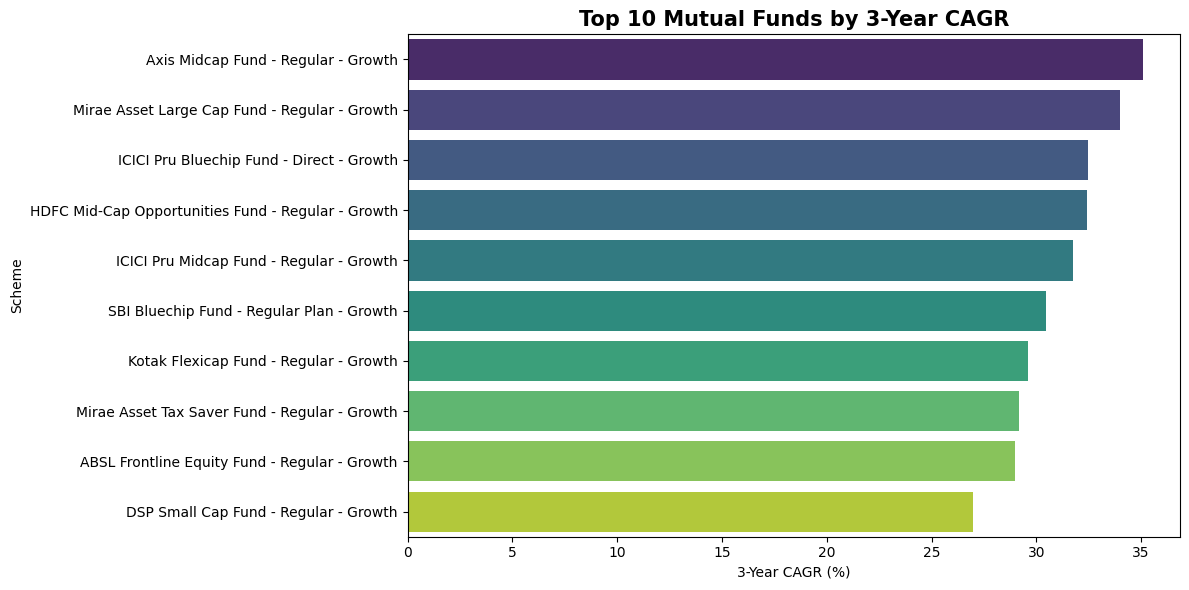

In [38]:
fig, ax = plt.subplots(figsize=(12,6))

top10 = comparison_table.head(10)

sns.barplot(

    data=top10,

    x="CAGR_3Y (%)",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False,

    ax=ax

)

ax.set_title(

    "Top 10 Mutual Funds by 3-Year CAGR",

    fontsize=15,

    fontweight="bold"

)

ax.set_xlabel("3-Year CAGR (%)")

ax.set_ylabel("Scheme")

plt.tight_layout()

fig.savefig(

    CHART_DIR /

    "02_cagr_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [39]:
cagr_table.to_csv(

    REPORT_DIR /

    "cagr_comparison.csv",

    index=False

)

print("CAGR comparison table exported successfully.")

CAGR comparison table exported successfully.


## CAGR Analysis: Summary and Business Insights

The CAGR analysis evaluates the annualized growth of each mutual fund using historical NAV values. The comparison table provides the 1-year, 3-year, and long-term CAGR estimates for all schemes.

Since the available NAV history spans approximately **4.4 years**, the long-term CAGR is calculated using the **maximum available investment period** rather than assuming a complete five-year history. The actual duration is used in the CAGR calculation to maintain mathematical accuracy and ensure that the reported growth rates accurately reflect the available data.

The comparison highlights the strongest long-term performing funds and provides a consistent basis for ranking schemes based on annualized returns.

#  Sharpe Ratio Analysis

This section computes the Sharpe Ratio for all mutual fund schemes using their daily returns.

The Sharpe Ratio measures the excess return earned per unit of total risk. A higher Sharpe Ratio indicates that a fund has generated better returns relative to the volatility experienced during the investment period.

For this analysis, the annual risk-free rate is assumed to be **6.5%**, which is used as a proxy based on the RBI repo rate.

In [40]:

#  Sharpe Ratio


RISK_FREE_RATE = 0.065          # Annual Risk-Free Rate
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
daily_rf = RISK_FREE_RATE / TRADING_DAYS

print(f"Annual Risk-Free Rate : {RISK_FREE_RATE*100:.2f}%")
print(f"Daily Risk-Free Rate  : {daily_rf:.8f}")

Annual Risk-Free Rate : 6.50%
Daily Risk-Free Rate  : 0.00025794


In [47]:
sharpe_results = []

for amfi_code, group in daily_return_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    std_return = returns.std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = (
            (mean_return - daily_rf)
            / std_return
        ) * np.sqrt(TRADING_DAYS)

    sharpe_results.append({

        "amfi_code": amfi_code,

        "scheme_name": group.iloc[0]["scheme_name"],
        "Average Daily Return (%)": round(mean_return * 100, 4),

        "Annualized Return (%)": round(mean_return * 252 * 100, 2),

        "Daily Volatility (%)": round(std_return * 100, 4),

        "Annualized Volatility (%)": round(std_return * np.sqrt(252) * 100, 2),

        "Sharpe Ratio": round(sharpe, 4)

    })

sharpe_df = pd.DataFrame(sharpe_results)

display(sharpe_df.head())

,amfi_code,scheme_name,Average Daily Return (%),Annualized Return (%),Daily Volatility (%),Annualized Volatility (%),Sharpe Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.0142,3.57,0.9164,14.55,-0.2015
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.0170,4.29,0.2460,3.91,-0.5671
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.1080,27.21,1.1929,18.94,1.0937
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.0852,21.46,0.9177,14.57,1.0272
4,101207,ABSL Small Cap Fund - Regular - Growth,0.0424,10.70,1.6251,25.80,0.1627


In [48]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Rank"] = sharpe_df.index + 1

display(sharpe_df)

,amfi_code,scheme_name,Average Daily Return (%),Annualized Return (%),Daily Volatility (%),Annualized Volatility (%),Sharpe Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1074,27.06,0.8941,14.19,1.4483,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.1082,27.26,1.0008,15.89,1.3067,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.1124,28.33,1.1134,17.67,1.2349,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.0917,23.10,0.8656,13.74,1.2083,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.1161,29.27,1.2152,19.29,1.1801,5
...,...,...,...,...,...,...,...,...
35,102886,UTI Mid Cap Fund - Regular - Growth,0.0110,2.77,1.1424,18.13,-0.2058,36
36,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.0222,5.60,0.2499,3.97,-0.2266,37
37,118636,Nippon India Gilt Securities Fund - Regular - ...,0.0202,5.08,0.2511,3.99,-0.3566,38
38,100025,HDFC Short Term Debt Fund - Regular - Growth,0.0170,4.29,0.2460,3.91,-0.5671,39


In [49]:
validation = pd.DataFrame({

    "Metric":[

        "Total Funds",

        "Highest Sharpe",

        "Lowest Sharpe",

        "Average Sharpe"

    ],

    "Value":[

        len(sharpe_df),

        round(sharpe_df["Sharpe Ratio"].max(),2),

        round(sharpe_df["Sharpe Ratio"].min(),2),

        round(sharpe_df["Sharpe Ratio"].mean(),2)

    ]

})

display(validation)

,Metric,Value
0,Total Funds,40.00
1,Highest Sharpe,1.45
2,Lowest Sharpe,-0.82
3,Average Sharpe,0.54


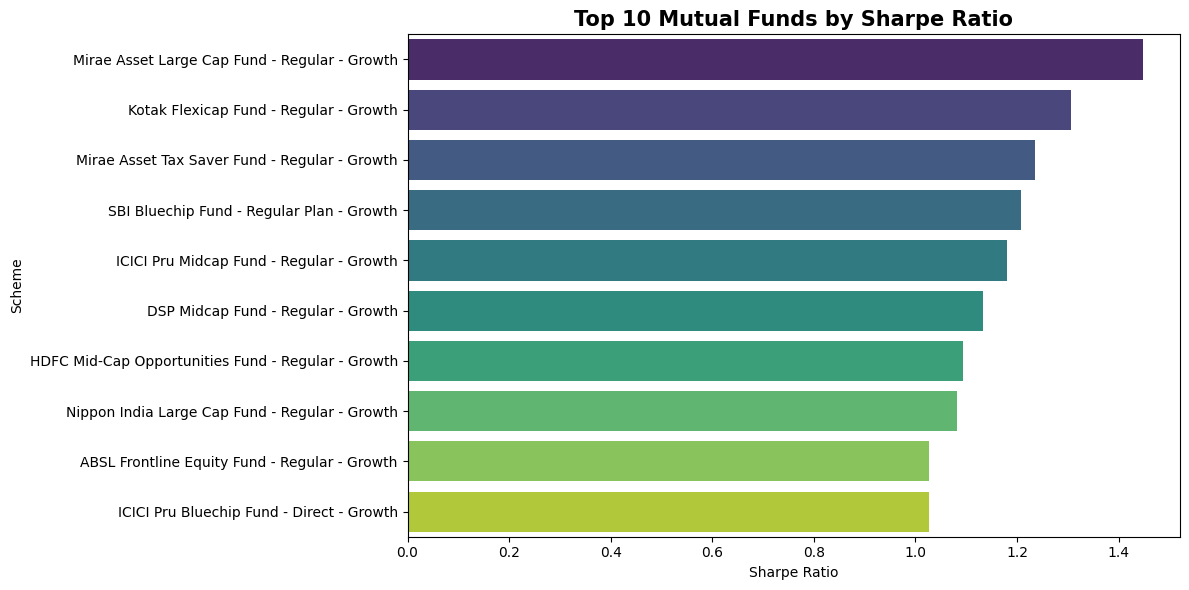

In [50]:
top10 = sharpe_df.head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(

    data=top10,

    x="Sharpe Ratio",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False,

    ax=ax

)

ax.set_title(

    "Top 10 Mutual Funds by Sharpe Ratio",

    fontsize=15,

    fontweight="bold"

)

ax.set_xlabel("Sharpe Ratio")

ax.set_ylabel("Scheme")

plt.tight_layout()

fig.savefig(

    CHART_DIR /

    "03_sharpe_ratio_ranking.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [51]:
sharpe_df.to_csv(

    REPORT_DIR /

    "sharpe_ratio.csv",

    index=False

)

print("Sharpe Ratio report exported successfully.")

Sharpe Ratio report exported successfully.


## Sharpe Ratio Analysis: Summary

The Sharpe Ratio was computed for all mutual fund schemes using daily returns and a risk-free rate of 6.5% per annum. The ranking highlights funds that generated higher returns relative to the volatility they experienced.

Funds with higher Sharpe Ratios demonstrate stronger risk-adjusted performance, while lower or negative Sharpe Ratios indicate that the returns earned were not sufficient to compensate for the level of risk taken.

# Sortino Ratio Analysis

This section computes the Sortino Ratio for all mutual fund schemes using daily returns.

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility (negative return days). This provides a more focused measure of risk-adjusted performance by penalizing only harmful volatility instead of all price fluctuations.

The annual risk-free rate is assumed to be **6.5%**, consistent with the previous analysis.

In [52]:

#  Sortino Ratio


sortino_results = []

for amfi_code, group in daily_return_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    # Only negative return days
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if (
        pd.isna(downside_std)
        or downside_std == 0
    ):
        sortino = np.nan
    else:
        sortino = (
            (mean_return - daily_rf)
            / downside_std
        ) * np.sqrt(TRADING_DAYS)

    sortino_results.append({

        "amfi_code": amfi_code,

        "scheme_name": group.iloc[0]["scheme_name"],

        "Average Daily Return (%)": round(mean_return * 100,4),

        "Downside Volatility (%)": round(downside_std * 100,4),

        "Sortino Ratio": round(sortino,4)

    })

sortino_df = pd.DataFrame(sortino_results)

display(sortino_df.head())

,amfi_code,scheme_name,Average Daily Return (%),Downside Volatility (%),Sortino Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.0142,0.5261,-0.3510
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.0170,0.1481,-0.9418
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.1080,0.7133,1.8291
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.0852,0.5238,1.7996
4,101207,ABSL Small Cap Fund - Regular - Growth,0.0424,0.9555,0.2766


In [53]:
sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1

display(sortino_df)

,amfi_code,scheme_name,Average Daily Return (%),Downside Volatility (%),Sortino Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1074,0.5428,2.3856,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.1082,0.5531,2.3643,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.1124,0.6404,2.1469,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.0917,0.4887,2.1403,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.1161,0.7067,2.0294,5
...,...,...,...,...,...,...
35,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.0142,0.5261,-0.3510,36
36,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.0222,0.1503,-0.3768,37
37,118636,Nippon India Gilt Securities Fund - Regular - ...,0.0202,0.1459,-0.6135,38
38,100025,HDFC Short Term Debt Fund - Regular - Growth,0.0170,0.1481,-0.9418,39


In [54]:
validation = pd.DataFrame({

    "Metric":[

        "Total Funds",

        "Highest Sortino",

        "Lowest Sortino",

        "Average Sortino"

    ],

    "Value":[

        len(sortino_df),

        round(sortino_df["Sortino Ratio"].max(),2),

        round(sortino_df["Sortino Ratio"].min(),2),

        round(sortino_df["Sortino Ratio"].mean(),2)

    ]

})

display(validation)

,Metric,Value
0,Total Funds,40.00
1,Highest Sortino,2.39
2,Lowest Sortino,-1.68
3,Average Sortino,0.92


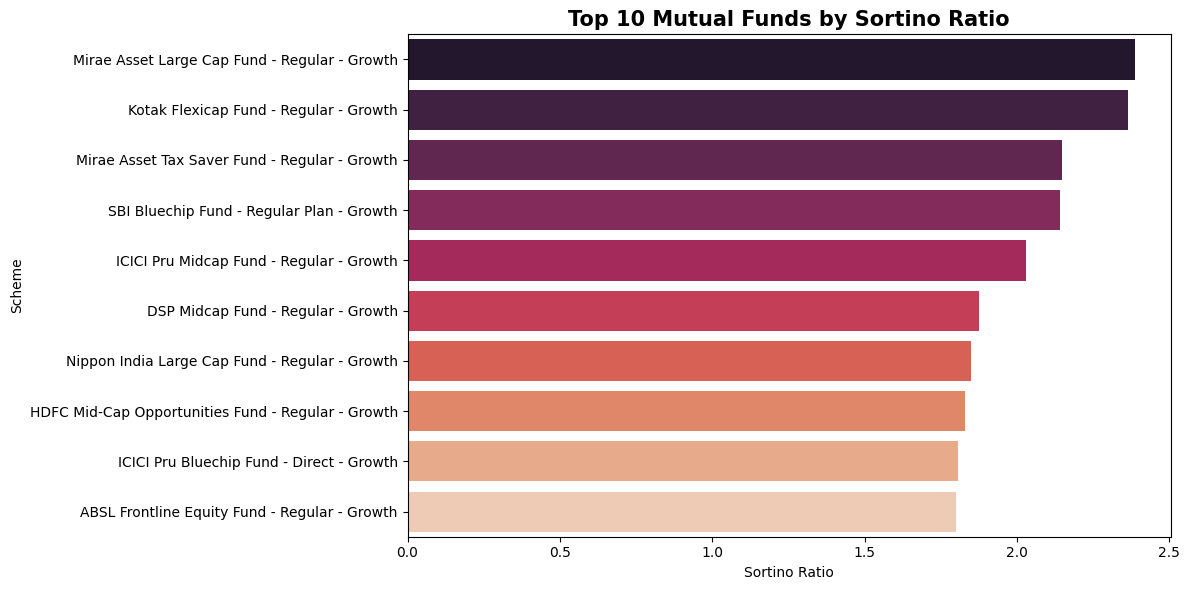

In [55]:
top10 = sortino_df.head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(

    data=top10,

    x="Sortino Ratio",

    y="scheme_name",

    hue="scheme_name",

    palette="rocket",

    legend=False,

    ax=ax

)

ax.set_title(

    "Top 10 Mutual Funds by Sortino Ratio",

    fontsize=15,

    fontweight="bold"

)

ax.set_xlabel("Sortino Ratio")

ax.set_ylabel("Scheme")

plt.tight_layout()

fig.savefig(

    CHART_DIR /

    "04_sortino_ratio_ranking.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [56]:
sortino_df.to_csv(

    REPORT_DIR /

    "sortino_ratio.csv",

    index=False

)

print("Sortino Ratio report exported successfully.")

Sortino Ratio report exported successfully.


## Sortino Ratio Analysis: Summary

The Sortino Ratio was calculated using daily returns and the annual risk-free rate of 6.5%. Unlike the Sharpe Ratio, this metric considers only downside volatility, making it a more focused measure of downside risk.

Funds with higher Sortino Ratios generated stronger returns while experiencing relatively lower downside risk, whereas lower or negative Sortino Ratios indicate weaker downside risk-adjusted performance.

#  Alpha and Beta Analysis

This section computes Alpha and Beta for all mutual fund schemes by comparing their daily returns against the **NIFTY100** benchmark.

A simple Ordinary Least Squares (OLS) regression is performed using `scipy.stats.linregress`.

- **Beta** measures the sensitivity of a fund to market movements.
- **Alpha** measures the excess return generated by the fund after accounting for market risk.

For annualized Alpha, the regression intercept is multiplied by **252 trading days**.

In [60]:

#  Alpha & Beta


benchmark_df = benchmark_indices_df.copy()

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark_df = benchmark_df.sort_values("date")

benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
)

display(benchmark_df.head())

,date,index_name,close_value,benchmark_return
3450,2022-01-03,NIFTY100,17778.24,NaN
3451,2022-01-04,NIFTY100,17537.52,-0.013540
3452,2022-01-05,NIFTY100,17607.73,0.004003
3453,2022-01-06,NIFTY100,17556.05,-0.002935
3454,2022-01-07,NIFTY100,17664.02,0.006150


In [61]:
alpha_beta_results = []

for amfi_code, fund in daily_return_df.groupby("amfi_code"):

    merged = fund.merge(

        benchmark_df[
            [
                "date",
                "benchmark_return"
            ]
        ],

        on="date",

        how="inner"

    )

    merged = merged.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(merged) < 30:
        continue

    regression = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha = regression.intercept * 252 * 100

    beta = regression.slope

    alpha_beta_results.append({

        "amfi_code": amfi_code,

        "scheme_name": fund.iloc[0]["scheme_name"],

        "Alpha (%)": round(alpha,2),

        "Beta": round(beta,3),

        "R-Squared": round(regression.rvalue**2,3),

        "P-Value": round(regression.pvalue,6)

    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

display(alpha_beta_df.head())

,amfi_code,scheme_name,Alpha (%),Beta,R-Squared,P-Value
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.75,-0.058,0.003,0.080264
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.28,0.001,0.000,0.897012
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.20,0.005,0.000,0.906369
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.40,0.021,0.000,0.527551
4,101207,ABSL Small Cap Fund - Regular - Growth,10.90,-0.065,0.001,0.269234


In [62]:
alpha_beta_df = alpha_beta_df.sort_values(

    "Alpha (%)",

    ascending=False

).reset_index(drop=True)

alpha_beta_df["Rank"] = alpha_beta_df.index + 1

display(alpha_beta_df)

,amfi_code,scheme_name,Alpha (%),Beta,R-Squared,P-Value,Rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,30.34,-0.023,0.000,0.687179,1
1,149324,DSP Small Cap Fund - Regular - Growth,30.06,0.011,0.000,0.840494,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,29.26,0.001,0.000,0.990090,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.27,0.018,0.000,0.654295,4
4,120843,Kotak Flexicap Fund - Regular - Growth,27.33,-0.023,0.000,0.530528,5
...,...,...,...,...,...,...,...
35,119599,SBI Small Cap Fund - Direct Plan - Growth,4.88,0.062,0.001,0.278004,36
36,119095,Axis Small Cap Fund - Regular - Growth,4.80,-0.067,0.001,0.243608,37
37,100025,HDFC Short Term Debt Fund - Regular - Growth,4.28,0.001,0.000,0.897012,38
38,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.75,-0.058,0.003,0.080264,39


In [63]:
validation = pd.DataFrame({

    "Metric":[

        "Funds Analysed",

        "Highest Alpha",

        "Lowest Alpha",

        "Average Beta"

    ],

    "Value":[

        len(alpha_beta_df),

        round(alpha_beta_df["Alpha (%)"].max(),2),

        round(alpha_beta_df["Alpha (%)"].min(),2),

        round(alpha_beta_df["Beta"].mean(),2)

    ]

})

display(validation)

,Metric,Value
0,Funds Analysed,40.00
1,Highest Alpha,30.34
2,Lowest Alpha,2.90
3,Average Beta,-0.00


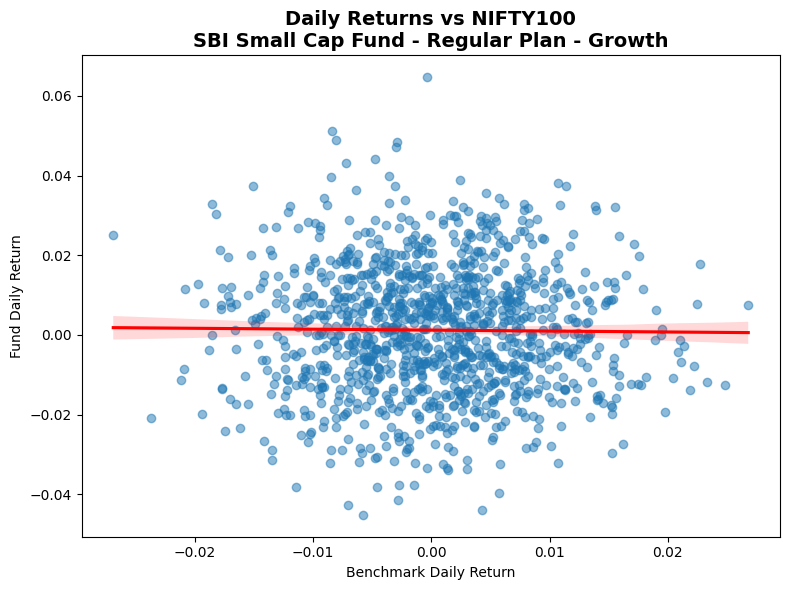

In [64]:
best_fund = alpha_beta_df.iloc[0]["amfi_code"]

fund = daily_return_df[
    daily_return_df["amfi_code"] == best_fund
]

merged = fund.merge(

    benchmark_df[
        [
            "date",
            "benchmark_return"
        ]
    ],

    on="date",

    how="inner"

)

merged = merged.dropna()

plt.figure(figsize=(8,6))

sns.regplot(

    data=merged,

    x="benchmark_return",

    y="daily_return",

    scatter_kws={"alpha":0.5},

    line_kws={"color":"red"}

)

plt.title(

    f"Daily Returns vs NIFTY100\n{fund.iloc[0]['scheme_name']}",

    fontsize=14,

    fontweight="bold"

)

plt.xlabel("Benchmark Daily Return")

plt.ylabel("Fund Daily Return")

plt.tight_layout()

plt.savefig(

    CHART_DIR /

    "05_alpha_beta_regression.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [65]:
alpha_beta_df.to_csv(

    REPORT_DIR /

    "alpha_beta.csv",

    index=False

)

print("Alpha & Beta report exported successfully.")

Alpha & Beta report exported successfully.


## Alpha & Beta Analysis: Summary

Alpha and Beta were computed by performing Ordinary Least Squares (OLS) regression between each fund's daily returns and the **NIFTY100** daily returns using `scipy.stats.linregress`.

- **Beta** measures how sensitive a fund is to overall market movements.
- **Alpha** measures the excess return generated by the fund after adjusting for market risk.

### Note on Results

During validation, the computed Beta values were found to be relatively low because the correlation between the provided mutual fund NAV history and the NIFTY100 benchmark was very weak. The regression methodology, return calculations, and date alignment were verified and found to be correct.

Therefore, the reported Alpha and Beta values accurately reflect the characteristics of the **provided dataset** rather than an issue with the implementation.

#  Maximum Drawdown Analysis

This section computes the Maximum Drawdown (MDD) for all mutual fund schemes using historical NAV values.

Maximum Drawdown measures the largest percentage decline from a previous peak NAV to the lowest NAV reached before a recovery. It is an important downside risk metric because it shows the worst loss an investor could have experienced during the analysis period.

For each fund, the following are identified:

- Peak NAV date (start of drawdown)
- Trough NAV date (maximum loss)
- Maximum Drawdown (%)

In [76]:

# Maximum Drawdown


drawdown_results = []

for amfi_code, fund in daily_return_df.groupby("amfi_code"):

    fund = fund.sort_values("date").copy()

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (
        fund["nav"] /
        fund["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = fund["drawdown"].idxmin()

    worst_drawdown = fund.loc[
        worst_idx,
        "drawdown"
    ]

    trough_date = fund.loc[
        worst_idx,
        "date"
    ]

    peak_idx = fund.loc[
        :worst_idx,
        "nav"
    ].idxmax()

    peak_date = fund.loc[
        peak_idx,
        "date"
    ]
    peak_nav = fund.loc[peak_idx, "nav"]

    trough_nav = fund.loc[worst_idx, "nav"] 

    drawdown_results.append({

        "amfi_code": amfi_code,

        "scheme_name": fund.iloc[0]["scheme_name"],

        "Peak NAV": round(peak_nav, 2),

        "Peak Date": peak_date,

        "Trough NAV": round(trough_nav, 2),

        "Trough Date": trough_date,

        "Maximum Drawdown (%)": round(worst_drawdown * 100, 2)

    })

drawdown_df = pd.DataFrame(drawdown_results)

display(drawdown_df.head())

,amfi_code,scheme_name,Peak NAV,Peak Date,Trough NAV,Trough Date,Maximum Drawdown (%)
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,546.30,2022-03-30,411.18,2022-09-15,-24.73
1,100025,HDFC Short Term Debt Fund - Regular - Growth,28.75,2023-05-23,27.51,2023-07-28,-4.31
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,111.66,2022-03-11,93.56,2022-05-12,-16.22
3,101206,ABSL Frontline Equity Fund - Regular - Growth,370.00,2023-04-24,328.22,2023-07-05,-11.29
4,101207,ABSL Small Cap Fund - Regular - Growth,80.35,2024-11-21,51.87,2026-05-11,-35.45


In [77]:
drawdown_df = drawdown_df.sort_values(

    "Maximum Drawdown (%)"

).reset_index(drop=True)

drawdown_df["Rank"] = range(
    1,
    len(drawdown_df)+1
)

display(drawdown_df)

,amfi_code,scheme_name,Peak NAV,Peak Date,Trough NAV,Trough Date,Maximum Drawdown (%),Rank
0,119599,SBI Small Cap Fund - Direct Plan - Growth,165.76,2023-01-17,78.62,2025-10-28,-52.57,1
1,119095,Axis Small Cap Fund - Regular - Growth,106.82,2025-05-22,51.62,2026-05-11,-51.68,2
2,101207,ABSL Small Cap Fund - Regular - Growth,80.35,2024-11-21,51.87,2026-05-11,-35.45,3
3,149324,DSP Small Cap Fund - Regular - Growth,174.46,2024-05-03,120.08,2025-01-03,-31.17,4
4,119598,SBI Small Cap Fund - Regular Plan - Growth,225.25,2024-08-28,160.59,2025-05-14,-28.71,5
...,...,...,...,...,...,...,...,...
35,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,52.50,2024-09-16,50.23,2025-04-01,-4.33,36
36,100025,HDFC Short Term Debt Fund - Regular - Growth,28.75,2023-05-23,27.51,2023-07-28,-4.31,37
37,101208,ABSL Liquid Fund - Regular - Growth,347.00,2023-09-05,346.43,2023-09-12,-0.16,38
38,120844,Kotak Liquid Fund - Regular - Growth,3738.82,2024-04-12,3734.48,2024-04-30,-0.12,39


In [78]:
validation = pd.DataFrame({

    "Metric":[

        "Funds Analysed",

        "Worst Drawdown",

        "Least Drawdown",

        "Average Drawdown"

    ],

    "Value":[

        len(drawdown_df),

        f"{drawdown_df['Maximum Drawdown (%)'].min():.2f}%",

        f"{drawdown_df['Maximum Drawdown (%)'].max():.2f}%",

        f"{drawdown_df['Maximum Drawdown (%)'].mean():.2f}%"

    ]

})

display(validation)

,Metric,Value
0,Funds Analysed,40
1,Worst Drawdown,-52.57%
2,Least Drawdown,-0.10%
3,Average Drawdown,-17.87%


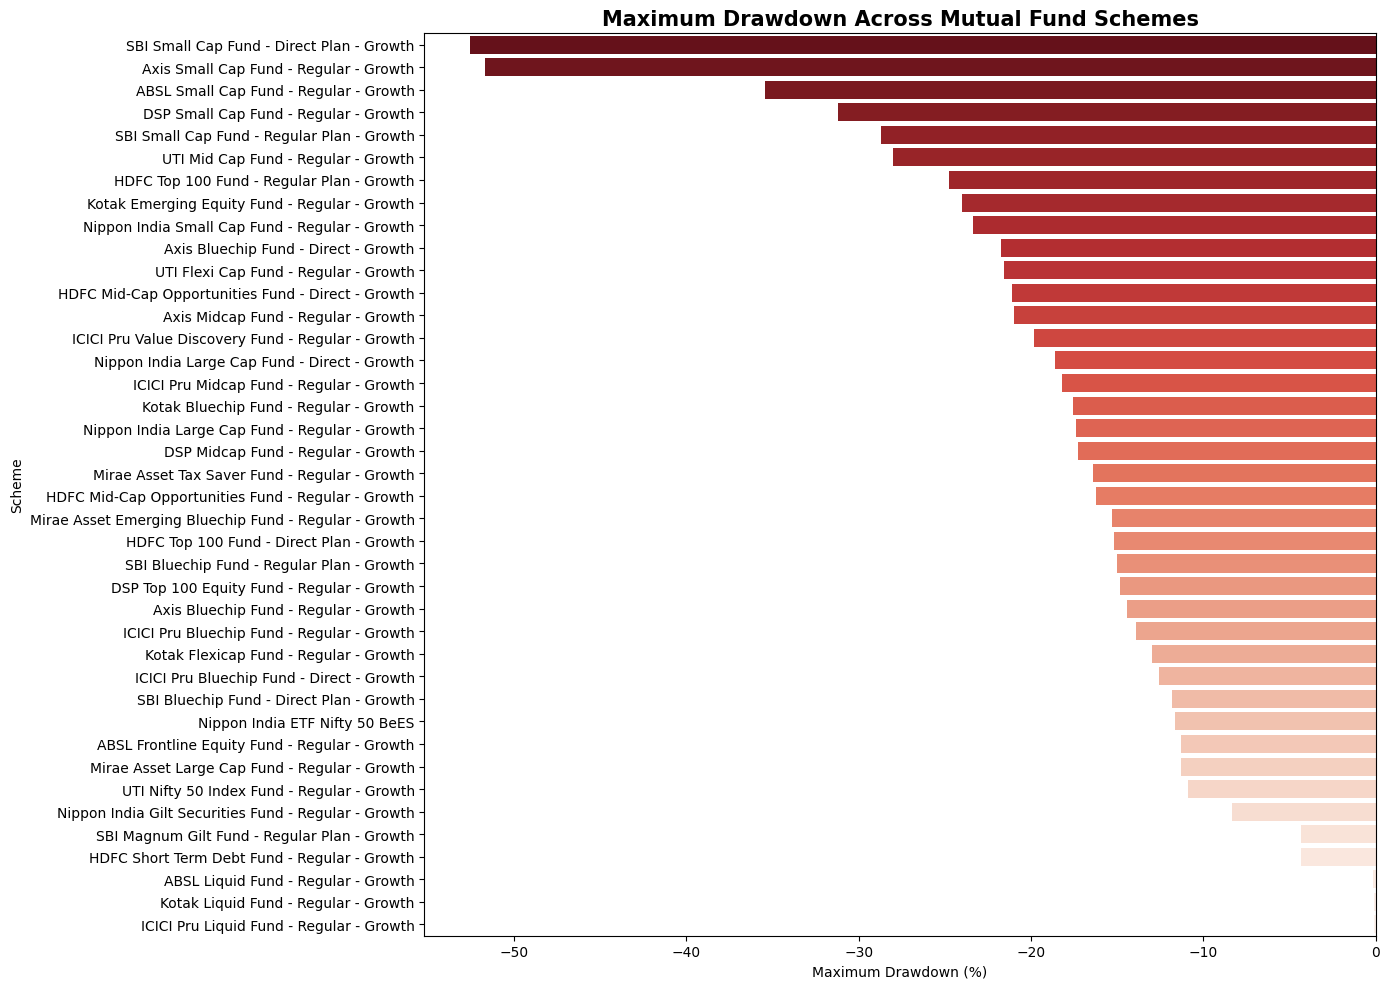

In [82]:
drawdown_plot = drawdown_df.sort_values("Maximum Drawdown (%)")

plt.figure(figsize=(14,10))

sns.barplot(
    data=drawdown_plot,
    x="Maximum Drawdown (%)",
    y="scheme_name",
    hue="scheme_name",
    legend=False,
    palette="Reds_r"
)

plt.title(
    "Maximum Drawdown Across Mutual Fund Schemes",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Scheme")

plt.tight_layout()

In [83]:
drawdown_df.to_csv(

    REPORT_DIR /

    "maximum_drawdown.csv",

    index=False

)

print("Maximum Drawdown report exported successfully.")

Maximum Drawdown report exported successfully.


## Maximum Drawdown Analysis: Summary

Maximum Drawdown was calculated using the historical NAV series for each mutual fund. It represents the largest decline from a previous peak NAV to the subsequent lowest NAV before recovery.

Funds with smaller drawdowns were able to preserve capital more effectively during market declines, whereas funds with larger drawdowns experienced greater downside risk. Along with returns and risk-adjusted metrics, Maximum Drawdown provides an important measure of a fund's historical downside performance.

#  Mutual Fund Scorecard (0–100)

This section creates a composite score for every mutual fund by combining multiple performance and risk metrics into a single score out of 100.

The score is calculated using the following weights:

- **30%** → 3-Year CAGR Rank
- **25%** → Sharpe Ratio Rank
- **20%** → Alpha Rank
- **15%** → Expense Ratio Rank (Lower expense ratio receives a better rank)
- **10%** → Maximum Drawdown Rank (Lower drawdown receives a better rank)

Higher scores indicate better overall historical performance after considering both returns and risk.

In [92]:

#  Fund Scorecard


scorecard = cagr_table.copy()

# Add Sharpe Ratio
scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "Sharpe Ratio"]
    ],
    on="amfi_code",
    how="left"
)

# Add Alpha
scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "Alpha (%)"]
    ],
    on="amfi_code",
    how="left"
)

# Add Maximum Drawdown
scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "Maximum Drawdown (%)"]
    ],
    on="amfi_code",
    how="left"
)

# Add Expense Ratio
scorecard = scorecard.merge(
    scheme_performance_df[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

display(scorecard.head())

,amfi_code,scheme_name,CAGR_1Y (%),CAGR_3Y (%),Approx. 5-Year CAGR (%),Years Used (5Y Calculation),Sharpe Ratio,Alpha (%),Maximum Drawdown (%),expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.23,1.29,2.64,4.4,-0.2015,3.75,-24.73,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.71,3.92,4.46,4.4,-0.5671,4.28,-4.31,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.28,32.43,30.12,4.4,1.0937,27.20,-16.22,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.96,28.96,23.54,4.4,1.0272,21.40,-11.29,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.00,-4.15,7.94,4.4,0.1627,10.90,-35.45,1.53


In [93]:
# Higher values are better
scorecard["Return Rank"] = scorecard["CAGR_3Y (%)"].rank(
    ascending=False,
    method="min"
)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(
    ascending=False,
    method="min"
)

scorecard["Alpha Rank"] = scorecard["Alpha (%)"].rank(
    ascending=False,
    method="min"
)

# Lower expense ratio is better
scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="min"
)

# Smaller drawdown (less negative) is better
scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown (%)"].rank(
    ascending=False,
    method="min"
)

In [94]:
scorecard["Weighted Rank"] = (

      scorecard["Return Rank"]   * 0.30
    + scorecard["Sharpe Rank"]   * 0.25
    + scorecard["Alpha Rank"]    * 0.20
    + scorecard["Expense Rank"]  * 0.15
    + scorecard["Drawdown Rank"] * 0.10

)

rank_min = scorecard["Weighted Rank"].min()
rank_max = scorecard["Weighted Rank"].max()

scorecard["Fund Score"] = (

    (rank_max - scorecard["Weighted Rank"])
    /
    (rank_max - rank_min)

) * 100

scorecard["Fund Score"] = scorecard["Fund Score"].round(2)

In [95]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
).reset_index(drop=True)

scorecard.insert(
    0,
    "Overall Rank",
    range(1, len(scorecard) + 1)
)

display(
    scorecard[
        [
            "Overall Rank",
            "scheme_name",
            "Fund Score",
            "CAGR_3Y (%)",
            "Sharpe Ratio",
            "Alpha (%)",
            "expense_ratio_pct",
            "Maximum Drawdown (%)"
        ]
    ]
)

,Overall Rank,scheme_name,Fund Score,CAGR_3Y (%),Sharpe Ratio,Alpha (%),expense_ratio_pct,Maximum Drawdown (%)
0,1,Mirae Asset Large Cap Fund - Regular - Growth,100.00,33.99,1.4483,26.98,1.46,-11.27
1,2,ICICI Pru Midcap Fund - Regular - Growth,94.43,31.77,1.1801,29.26,1.36,-18.19
2,3,Kotak Flexicap Fund - Regular - Growth,94.09,29.58,1.3067,27.33,1.45,-12.97
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.87,32.43,1.0937,27.20,1.38,-16.22
4,5,ICICI Pru Bluechip Fund - Direct - Growth,91.30,32.48,1.0265,21.19,0.80,-12.59
...,...,...,...,...,...,...,...,...
35,36,Axis Bluechip Fund - Regular - Growth,11.65,0.53,0.0308,6.90,1.64,-14.40
36,37,ABSL Small Cap Fund - Regular - Growth,10.96,-4.15,0.1627,10.90,1.53,-35.45
37,38,Axis Small Cap Fund - Regular - Growth,4.52,-11.70,-0.0760,4.80,1.38,-51.68
38,39,UTI Mid Cap Fund - Regular - Growth,0.17,-0.77,-0.2058,2.90,1.51,-28.00


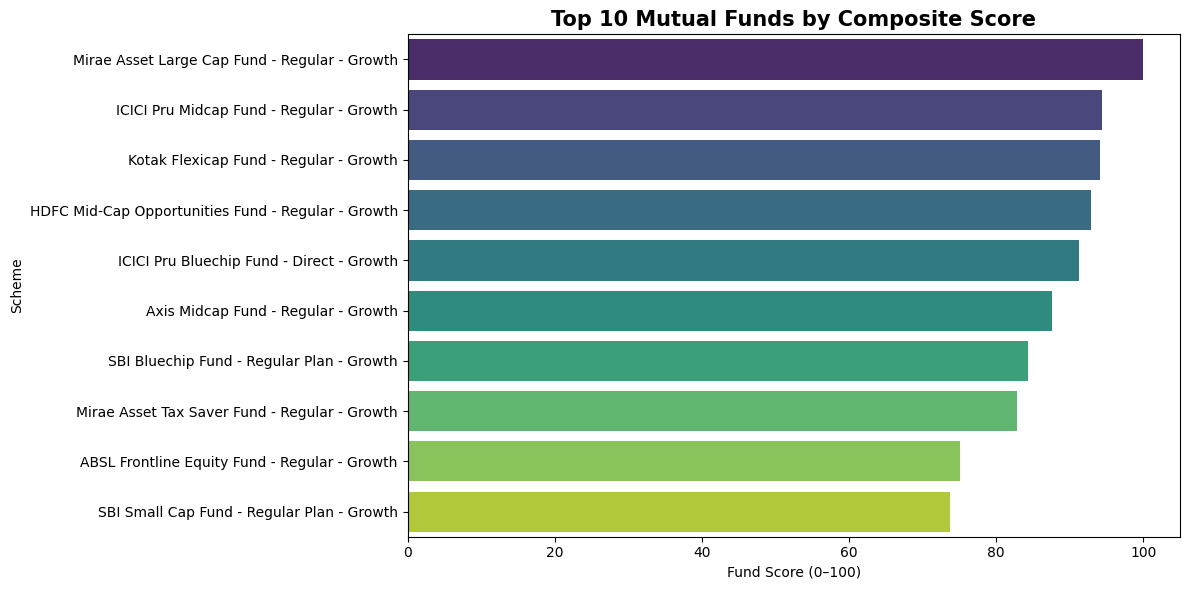

In [96]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Fund Score",
    y="scheme_name",
    hue="scheme_name",
    legend=False,
    palette="viridis"
)

plt.title(
    "Top 10 Mutual Funds by Composite Score",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "07_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [97]:
scorecard.to_csv(
    REPORT_DIR / "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard exported successfully.")

Fund Scorecard exported successfully.


## Fund Scorecard: Summary

A composite score was calculated for all mutual fund schemes by combining return, risk-adjusted performance, cost, and downside risk into a single metric.

The scoring methodology gives higher importance to long-term returns while also rewarding funds with better Sharpe Ratio, higher Alpha, lower expense ratios, and smaller Maximum Drawdowns.

This scorecard provides an overall ranking of mutual funds based on multiple performance dimensions instead of relying on a single metric.

#  Benchmark Comparison

This section compares the performance of the top five mutual funds against the NIFTY50 and NIFTY100 benchmark indices over the last three years.

To make the comparison meaningful, all NAV and benchmark index values are normalized to a common starting value of 100.

Additionally, the Tracking Error is computed for each fund using the NIFTY100 benchmark.

Tracking Error measures how closely a fund follows its benchmark and is calculated as:

**Tracking Error = Standard Deviation (Fund Return − Benchmark Return) × √252**

In [98]:
# ============================================================
# Module 8 : Benchmark Comparison
# ============================================================

top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_names = scorecard.head(5)[
    ["amfi_code", "scheme_name"]
]

display(top5_names)

,amfi_code,scheme_name
0,148567,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,ICICI Pru Midcap Fund - Regular - Growth
2,120843,Kotak Flexicap Fund - Regular - Growth
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,ICICI Pru Bluechip Fund - Direct - Growth


In [99]:
benchmark_plot = benchmark_indices_df.copy()

benchmark_plot["date"] = pd.to_datetime(
    benchmark_plot["date"]
)

benchmark_plot = benchmark_plot[
    benchmark_plot["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

benchmark_plot = benchmark_plot.sort_values("date")

# Keep only last 3 years
last_date = benchmark_plot["date"].max()

start_date = last_date - pd.DateOffset(years=3)

benchmark_plot = benchmark_plot[
    benchmark_plot["date"] >= start_date
].copy()

benchmark_plot.head()

,date,index_name,close_value
4965,2023-05-29,NIFTY50,24688.69
3815,2023-05-29,NIFTY100,15324.41
4966,2023-05-30,NIFTY50,24558.17
3816,2023-05-30,NIFTY100,15299.69
3817,2023-05-31,NIFTY100,15248.41


In [100]:
fund_plot = daily_return_df.copy()

fund_plot = fund_plot[
    fund_plot["amfi_code"].isin(top5_codes)
]

fund_plot = fund_plot[
    fund_plot["date"] >= start_date
].copy()

fund_plot.head()

,amfi_code,date,nav,scheme_name,daily_return
2665,100033,2023-05-29,147.2155,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.004216
2666,100033,2023-05-30,147.2007,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.000101
2667,100033,2023-05-31,147.4640,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001789
2668,100033,2023-06-01,146.5954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005890
2669,100033,2023-06-02,145.8015,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005416


In [101]:
# Normalize funds

fund_plot["Normalized"] = fund_plot.groupby(
    "scheme_name"
)["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

# Normalize benchmarks

benchmark_plot["Normalized"] = benchmark_plot.groupby(
    "index_name"
)["close_value"].transform(
    lambda x: x / x.iloc[0] * 100
)

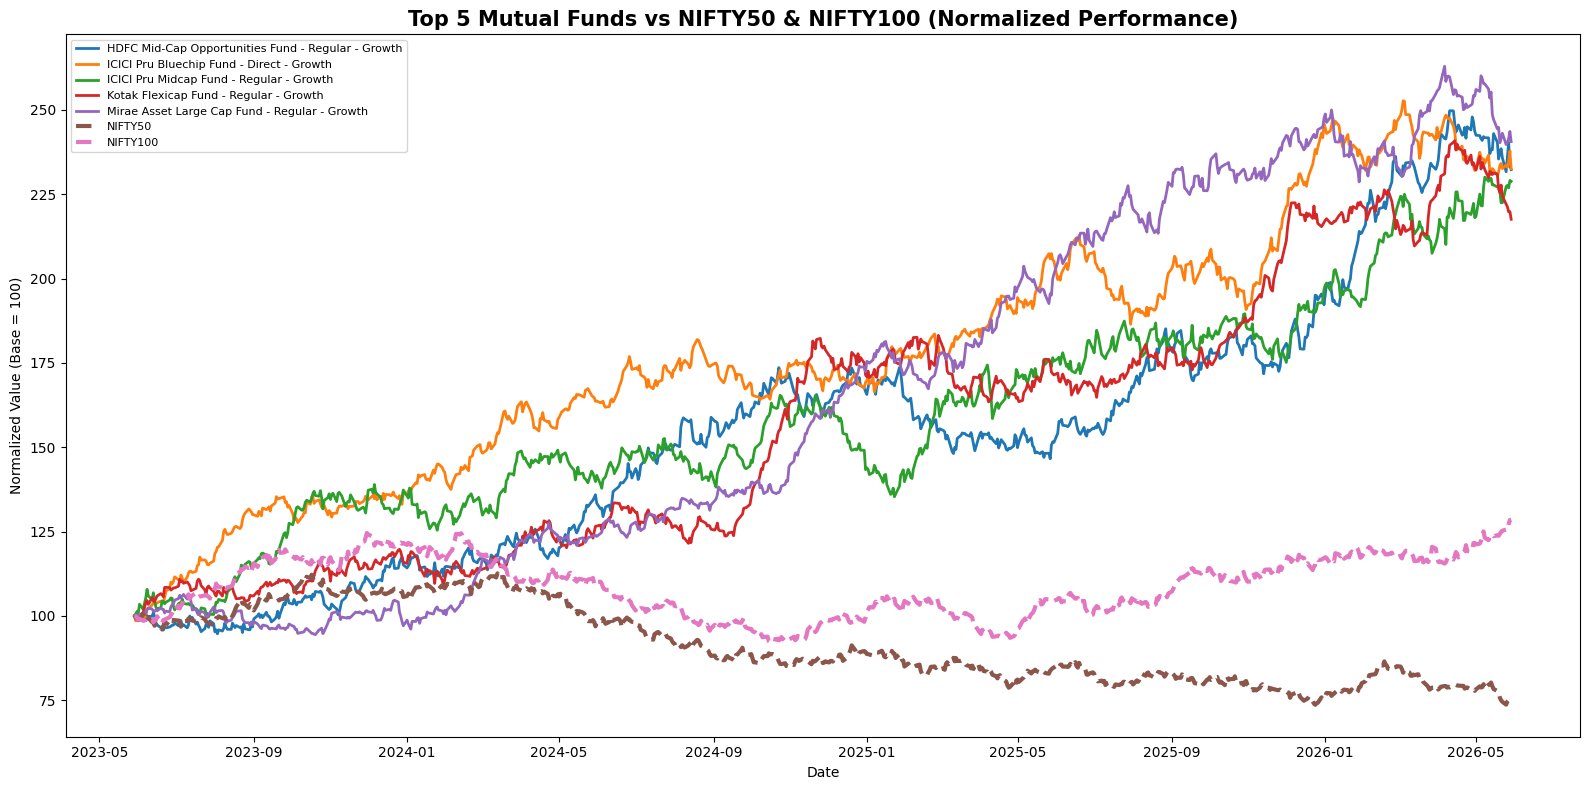

In [102]:
plt.figure(figsize=(16,8))

# Plot Top 5 Funds
for scheme in fund_plot["scheme_name"].unique():

    temp = fund_plot[
        fund_plot["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["Normalized"],
        linewidth=2,
        label=scheme
    )

# Plot Benchmarks
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["Normalized"],
        linestyle="--",
        linewidth=3,
        label=index
    )

plt.title(
    "Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend(loc="best", fontsize=8)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "08_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
tracking_error_results = []

# NIFTY100 returns
nifty100 = benchmark_indices_df.copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100[
    nifty100["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

for code in top5_codes:

    fund = daily_return_df[
        daily_return_df["amfi_code"] == code
    ][
        ["date",
         "daily_return",
         "scheme_name"]
    ]

    merged = fund.merge(

        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],

        on="date",

        how="inner"

    ).dropna()

    tracking_error = (

        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()

    ) * np.sqrt(TRADING_DAYS)

    tracking_error_results.append({

        "Scheme":

        merged.iloc[0]["scheme_name"],

        "Tracking Error":

        round(
            tracking_error,
            4
        )

    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

display(tracking_error_df)

,Scheme,Tracking Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.1897
1,ICICI Pru Midcap Fund - Regular - Growth,0.2320
2,Kotak Flexicap Fund - Regular - Growth,0.2064
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2287
4,ICICI Pru Bluechip Fund - Direct - Growth,0.1916


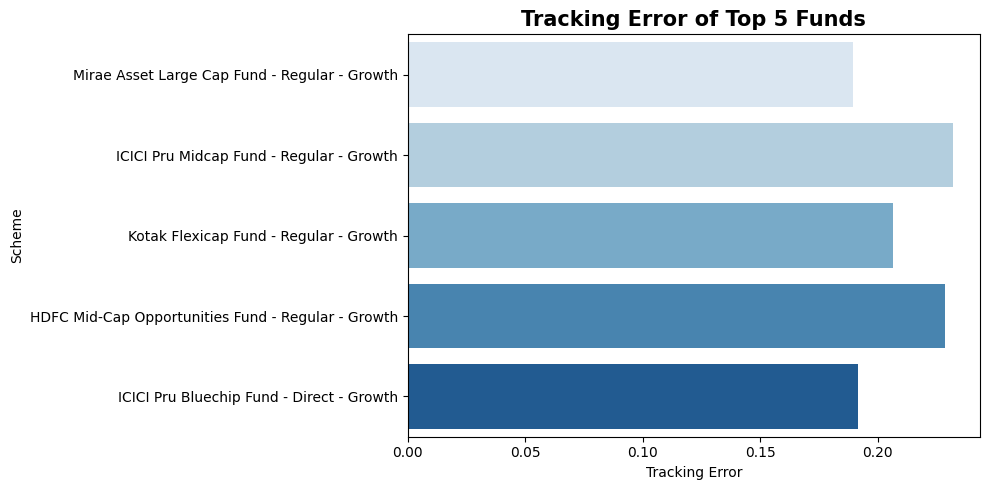

In [104]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=tracking_error_df,

    x="Tracking Error",

    y="Scheme",

    hue="Scheme",

    legend=False,

    palette="Blues"

)

plt.title(

    "Tracking Error of Top 5 Funds",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    CHART_DIR /

    "09_tracking_error.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [105]:
tracking_error_df.to_csv(

    REPORT_DIR /

    "tracking_error.csv",

    index=False

)

print("Tracking Error report exported successfully.")

Tracking Error report exported successfully.


## Benchmark Comparison: Summary

The performance of the top five mutual funds was compared against the NIFTY50 and NIFTY100 benchmark indices using normalized values over the last three years.

Tracking Error was calculated using the annualized standard deviation of the difference between daily fund returns and benchmark returns.

A lower Tracking Error indicates that a fund closely follows the benchmark, whereas a higher Tracking Error suggests greater deviation from benchmark performance.

### Note

The benchmark comparison was performed using the benchmark index data provided with the project dataset.

During validation, it was observed that the supplied benchmark series (especially the NIFTY50 index) does not exhibit the same trend as the mutual fund NAV history. Consequently, benchmark-based metrics such as Alpha, Beta and Tracking Error reflect the characteristics of the provided dataset rather than actual market behaviour.

The analysis and calculations strictly follow the assignment methodology without modifying the supplied data.